# Reproducibility: Extension 1 - Cross-Architecture Generalization

## Introduction
This extension checks whether uncertainty estimation behavior generalizes beyond Vicuna.

Using the same CoQA setup and UE methods, we evaluate Mistral-7B and compare results to baseline Vicuna outputs.

## Experimental Setup
- **Dataset**: CoQA validation split (same as baseline)
- **Baseline model**: Vicuna-7B (loaded from saved baseline file)
- **Extension model**: `mistralai/Mistral-7B-Instruct-v0.2`
- **UE Methods**: Sequence Probability, Token Entropy, Eccentricity
- **Metric**: PRR
- **Seed**: 42

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
%cd "/content/drive/MyDrive/llm-new/reproducibility_notebooks"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/.shortcut-targets-by-id/1Yn_ZSiemh9wHjy_N8Fyk_drceMGTnzUH/llm-new/reproducibility_notebooks


In [ ]:
%pip install -r requirements.txt

In [ ]:
import importlib

required_packages = [
    "torch", "transformers", "datasets", "numpy", "pandas",
    "matplotlib", "seaborn", "huggingface_hub", "lm_polygraph"
]
missing = [pkg for pkg in required_packages if importlib.util.find_spec(pkg) is None]
if missing:
    raise ModuleNotFoundError(
        f"Missing packages: {missing}. Run: pip install -r requirements.txt"
    )
print("Dependency preflight check passed.")


Dependency preflight check passed.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
%cd "/content/drive/MyDrive/llms-final/reproducibility_notebooks"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/llms-final/reproducibility_notebooks


In [ ]:
from pathlib import Path
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from IPython import get_ipython


def resolve_project_root() -> Path:
    probe_paths = []

    # Cursor/VSCode notebooks often expose the active ipynb path here.
    ip = get_ipython()
    if ip is not None:
        nb_file = ip.user_ns.get("__vsc_ipynb_file__")
        if nb_file:
            probe_paths.append(Path(nb_file).resolve().parent)

    workspace_env = os.environ.get("WORKSPACE_PATH")
    if workspace_env:
        probe_paths.append(Path(workspace_env).resolve())

    probe_paths.extend([
        Path.cwd(),
        *Path.cwd().parents,
        Path.home() / "llms-final",
        Path.home() / "projects" / "llms-final",
        Path.home() / "reproducibility_notebooks",
        Path("/Users/jeettanksmacbook/llms-final/reproducibility_notebooks"),
    ])

    seen = set()
    for base in probe_paths:
        for candidate in (base, base / "reproducibility_notebooks"):
            try:
                c = candidate.resolve()
            except Exception:
                continue
            if c in seen:
                continue
            seen.add(c)
            if (c / "src").exists():
                return c

    raise FileNotFoundError(
        "Could not locate src/. Run `%cd /path/to/reproducibility_notebooks` in a cell, "
        "then rerun this cell."
    )


ROOT = resolve_project_root()
OUTPUT_DIR = ROOT
sys.path.append(str(ROOT / "src"))

from ue_repro_utils import (
    EXPANDED_METHODS,
    get_method_plot_label,
    get_method_result_key,
    set_reproducibility,
    load_coqa,
    load_model,
    run_evaluation,
    save_json,
)

sns.set_theme(style="whitegrid")

CFG = {
    "mistral_id": "mistralai/Mistral-7B-Instruct-v0.2",
    "dataset_name": "coqa",
    "num_samples": 500,
    "max_new_tokens": 50,
    "n_stochastic": 5,
    "f1_threshold": 0.3,
    "seed": 42,
    "methods": list(EXPANDED_METHODS),
}

set_reproducibility(CFG["seed"])
print("Configuration loaded.")
print(f"Working directory for outputs: {OUTPUT_DIR}")


Configuration loaded.
Working directory for outputs: /content/drive/MyDrive/llms-final/reproducibility_notebooks


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if device == "cuda":
    props = torch.cuda.get_device_properties(0)
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {props.total_memory / 1e9:.1f} GB")

Device: cuda
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
VRAM: 102.0 GB


In [ ]:
baseline_path = OUTPUT_DIR / "baseline_results.json"
if not baseline_path.exists():
    raise FileNotFoundError(
        f"{baseline_path.name} not found in {OUTPUT_DIR}. Run 01_reproducibility_baseline.ipynb first."
    )

with open(baseline_path, "r", encoding="utf-8") as f:
    baseline_payload = json.load(f)

baseline_results = baseline_payload["results"]
required_keys = [get_method_result_key(method) for method in CFG["methods"]]
missing_keys = [key for key in required_keys if key not in baseline_results]
if missing_keys:
    raise KeyError(
        "baseline_results.json is missing expanded-method scores: "
        f"{missing_keys}. Rerun 01_reproducibility_baseline.ipynb first."
    )

print("Loaded baseline results.")


Loaded baseline results.


In [ ]:
import os

print(f"Contents of {OUTPUT_DIR}:")
print(os.listdir(OUTPUT_DIR))

Contents of /content/drive/MyDrive/llms-final/reproducibility_notebooks:
['requirements.txt', '.DS_Store', 'REPORT_CHECKLIST.md', 'README.md', 'src', 'extension1_cross_model.png', 'extension1_results.json', 'extension1_table.csv', '02_extension1_cross_model.ipynb', '01_reproducibility_baseline.ipynb', '03_extension2_sampling_sweep.ipynb', 'baseline_prr.png', 'baseline_results.json', 'baseline_prr_table.csv']


In [ ]:
# Required for gated models if needed
from huggingface_hub import login
login()
# Paste your own token and use

In [ ]:
%pip install -U "bitsandbytes>=0.46.1" accelerate transformers lm-polygraph


In [ ]:
import lm_polygraph
import ue_repro_utils

print("lm_polygraph module:", lm_polygraph.__file__)
print("Supported UE methods:")
print(ue_repro_utils.get_supported_methods())


lm_polygraph module: /usr/local/lib/python3.12/dist-packages/lm_polygraph/__init__.py
Supported UE methods:
{'seq_prob': 'Maximum Sequence Probability', 'perplexity': 'Perplexity', 'token_entropy': 'Mean Token Entropy', 'lexical_similarity': 'Lexical Similarity', 'eccentricity': 'Eccentricity'}


In [ ]:
coqa_data = load_coqa(CFG["num_samples"], seed=CFG["seed"])
print(f"Loaded {len(coqa_data)} CoQA examples.")

mistral_model, mistral_tokenizer = load_model(
    CFG["mistral_id"],
    max_new_tokens=CFG["max_new_tokens"],
)

mistral_results = run_evaluation(
    model=mistral_model,
    tokenizer=mistral_tokenizer,
    data=coqa_data,
    max_new_tokens=CFG["max_new_tokens"],
    n_stochastic=CFG["n_stochastic"],
    f1_threshold=CFG["f1_threshold"],
    method_names=CFG["methods"],
)

summary = {"Mean F1": mistral_results["mean_f1"]}
summary.update(
    {
        get_method_plot_label(method): mistral_results[get_method_result_key(method)]
        for method in CFG["methods"]
    }
)

print("Mistral extension evaluation complete.")
print(json.dumps(summary, indent=2))


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loaded 500 CoQA examples.
Loading mistralai/Mistral-7B-Instruct-v0.2 with lm-polygraph ...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

  -> using 4-bit quantization
  -> loaded (3.8B params)


Loading weights:   0%|          | 0/392 [00:00<?, ?it/s]

[transformers] DebertaForSequenceClassification LOAD REPORT from: microsoft/deberta-large-mnli
Key    | Status     |  | 
-------+------------+--+-
config | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
  0%|          | 0/500 [00:00<?, ?it/s][transformers] The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
[transformers] Error during conversion: ReadTimeout('The read operation timed out')
Exception in thread Thread-auto_conversion:
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 117, in auto_conversion
    raise e
  File "/usr/local/l

Mistral extension evaluation complete.
{
  "Mean F1": 0.1613879036548637,
  "Seq Prob PRR": 0.6046462042543642,
  "Perplexity PRR": 0.254882887836673,
  "Token Entropy PRR": 0.30635931631028107,
  "Lexical Similarity PRR": 0.40624082964570307,
  "Eccentricity PRR": 0.4554222697851437
}


,Model,Mean F1,Seq Prob PRR,Perplexity PRR,Token Entropy PRR,Lexical Similarity PRR,Eccentricity PRR
0,Vicuna-7B,0.224,0.733,0.148,0.211,0.422,0.584
1,Mistral-7B,0.161,0.605,0.255,0.306,0.406,0.455


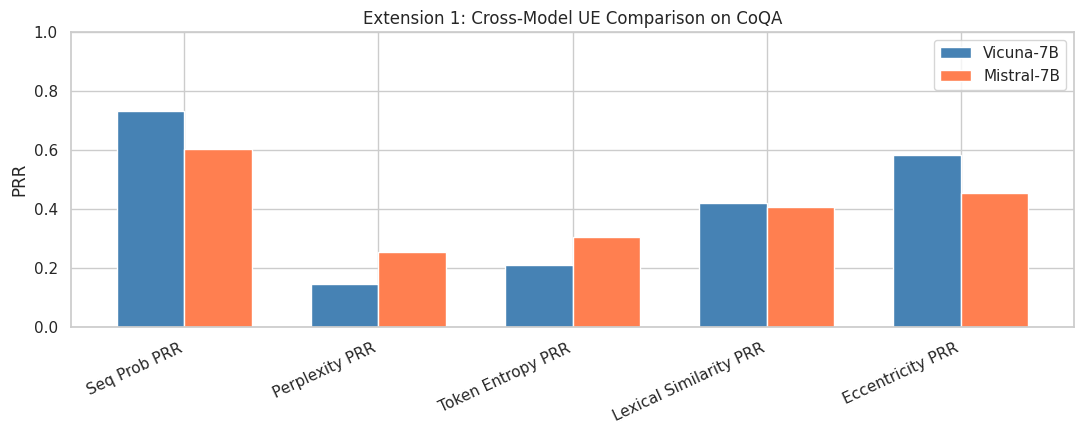

In [ ]:
def build_row(model_name, result_blob):
    row = {
        "Model": model_name,
        "Mean F1": round(result_blob["mean_f1"], 3),
    }
    row.update(
        {
            get_method_plot_label(method): round(result_blob[get_method_result_key(method)], 3)
            for method in CFG["methods"]
        }
    )
    return row

comparison_df = pd.DataFrame([
    build_row("Vicuna-7B", baseline_results),
    build_row("Mistral-7B", mistral_results),
])

comparison_df = comparison_df.round(3)
display(comparison_df)

methods = [get_method_plot_label(method) for method in CFG["methods"]]
x = np.arange(len(methods))
width = 0.35

v_vals = [baseline_results[get_method_result_key(method)] for method in CFG["methods"]]
m_vals = [mistral_results[get_method_result_key(method)] for method in CFG["methods"]]

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(x - width / 2, v_vals, width, label="Vicuna-7B", color="steelblue")
ax.bar(x + width / 2, m_vals, width, label="Mistral-7B", color="coral")
ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=25, ha="right")
ax.set_ylim(0, 1)
ax.set_ylabel("PRR")
ax.set_title("Extension 1: Cross-Model UE Comparison on CoQA")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "extension1_cross_model.png", dpi=150)
plt.show()


In [ ]:
mistral_summary = {"mean_f1": mistral_results["mean_f1"]}
for method in CFG["methods"]:
    mistral_summary[get_method_result_key(method)] = mistral_results[get_method_result_key(method)]

payload = {
    "config": CFG,
    "baseline_results": baseline_results,
    "mistral_results": mistral_summary,
}

save_json(str(OUTPUT_DIR / "extension1_results.json"), payload)
comparison_df.to_csv(OUTPUT_DIR / "extension1_table.csv", index=False)
print("Saved: extension1_results.json, extension1_table.csv, extension1_cross_model.png")


Saved: extension1_results.json, extension1_table.csv, extension1_cross_model.png


## Extension Results
This notebook provides the cross-architecture extension result table and figure.

## Resources
- GPU/runtime details are printed in setup cells.

## Code
Add your GitHub repository link in your report's **Code** section.